# Aula 02 - Detector de Movimento

![](../../data/imagem/banner-pos-2022.jpg)

-----------

# Importando Bibliotecas

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
PATH_DIR = '../../data'

video_path = os.path.join(PATH_DIR, 'video', 'video_01.mp4')
video_path

'../../data/video/video_01.mp4'

# Passo a passo do detector de movimento

In [3]:
# Cria um objeto de captura de vídeo
cap = cv2.VideoCapture(video_path)

## Ler os dois primeiros frames para comparação ##
### Frame 1 ###
ret, frame1 = cap.read()
prev_gray = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
prev_gray = cv2.GaussianBlur(prev_gray, (5, 5), 0)

## Frame 2 ##
ret, frame2 = cap.read()
gray = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)
gray = cv2.GaussianBlur(gray, (5, 5), 0)

## Subtração absoluta ##
diff = cv2.absdiff(prev_gray, gray)

## Threshold ##
_, thresh = cv2.threshold(diff, 25, 255, cv2.THRESH_BINARY)

## Dilatando a imagem binarizada ##
kernel = np.ones((3,3), np.uint8)
dilate = cv2.dilate(thresh, kernel, iterations=2)

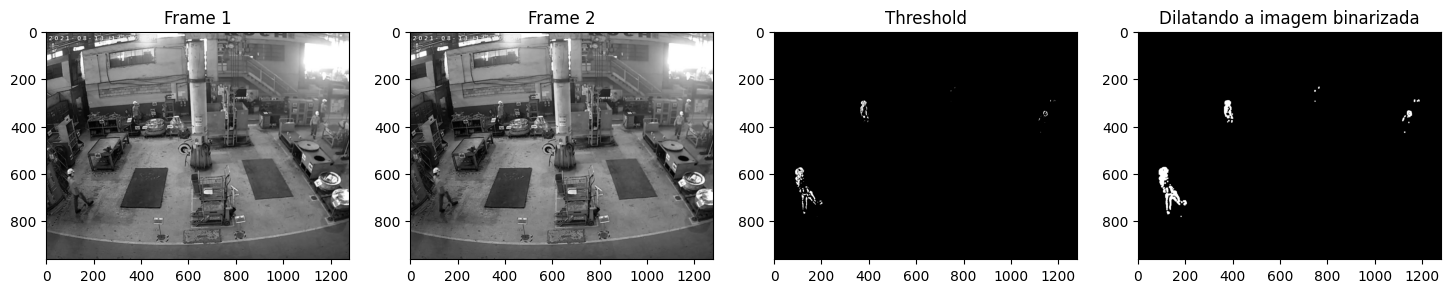

In [4]:
plt.figure(figsize=(18, 5))
plt.subplot(1, 4, 1)
plt.imshow(prev_gray, cmap='gray')
plt.title("Frame 1")

plt.subplot(1, 4, 2)
plt.imshow(gray, cmap='gray')
plt.title("Frame 2")

plt.subplot(1, 4, 3)
plt.imshow(thresh, cmap='gray')
plt.title("Threshold")

plt.subplot(1, 4, 4)
plt.imshow(dilate, cmap='gray')
plt.title("Dilatando a imagem binarizada")

plt.show()

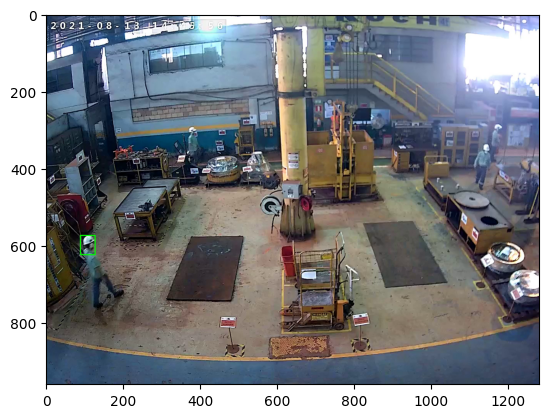

In [5]:
# Encontrando os contornos na imagem binarizada
contours, _ = cv2.findContours(
    thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

# Desenhando os retângulos ao redor dos contornos encontrados
for contour in contours:
    # Ignorar pequenos contornos (ruído)
    if cv2.contourArea(contour) < 500:
        continue
    
    # Obter as coordenadas do retângulo delimitador
    x, y, w, h = cv2.boundingRect(contour)

    # Desenhar o retângulo no frame original
    cv2.rectangle(frame2, (x,y), (x+w, y+h), (0,255,0), 2)

# Exibir o frame com os retângulos desenhados
plt.imshow(frame2[..., ::-1])  # Converter BGR para RGB
plt.show()

# Construção da função de detecção de movimento

In [6]:
def detector_de_movimento(video_path):
    cap = cv2.VideoCapture(video_path)

    ret, frame1 = cap.read()
    prev_gray = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    prev_gray = cv2.GaussianBlur(prev_gray, (5, 5), 0)

    while True:
        ret, frame2 = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)
        gray = cv2.GaussianBlur(gray, (5, 5), 0)

        # Subtração absoluta
        diff = cv2.absdiff(prev_gray, gray)

        # Threshold
        _, thresh = cv2.threshold(diff, 25, 255, cv2.THRESH_BINARY)

        # Remover ruído
        kernel = np.ones((3,3), np.uint8)
        thresh = cv2.dilate(thresh, kernel, iterations=2)

        # Encontrar contornos
        contours, _ = cv2.findContours(
            thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )

        for contour in contours:
            if cv2.contourArea(contour) < 500:
                continue
            
            x, y, w, h = cv2.boundingRect(contour)
            cv2.rectangle(frame2, (x,y), (x+w, y+h), (0,255,0), 2)

        cv2.imshow("Movimento", frame2)

        prev_gray = gray.copy()

        if cv2.waitKey(30) & 0xFF == 27:
            break

    cap.release()
    cv2.destroyAllWindows()

# Inferência

In [7]:
# Usando a função para detectar movimento no vídeo
detector_de_movimento(video_path=video_path)

In [8]:
# Usando a função para detectar movimento na webcam
detector_de_movimento(video_path=0)